# 05 — Split Analysis

Split strategy comparison and data leakage detection.

**Analyzer:** `SplitAnalyzer`  
**Outputs:** `split_analysis_report.md`, `summary.json`, `split_comparison.csv`, `split_class_balance.csv`

## Setup

In [1]:
import sys, time
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

NOTEBOOK_NAME = "05_split_analysis"
START_TIME = time.time()

from eda.utils.config import load_config
from eda.utils.logger import EDALogger
from eda.utils.metadata_loader import MetadataLoader
from eda.utils.wandb_manager import WandbManager
from eda.utils.plotting import PlotEngine, CATEGORICAL_COLOURS, DATASET_COLOURS
from eda.utils.report_generator import ReportGenerator
from eda.utils.system_monitor import SystemMonitor
from eda.utils.output_manager import OutputManager
from eda.utils.statistics import SplitAnalyzer
import pandas as pd
import matplotlib.pyplot as plt

config = load_config()
logger = EDALogger.setup(config, NOTEBOOK_NAME)
monitor = SystemMonitor()
plot_engine = PlotEngine(dpi=config.figure_dpi, formats=config.figure_formats)
output = OutputManager(config, NOTEBOOK_NAME)
snap_start = monitor.snapshot("start")
logger.log_start()

[22:11:15] INFO     ═══ EDA START: 05_split_analysis ═══ | EDA v1.0.0 | Python 3.13.2 | Windows


In [2]:
loader = MetadataLoader(config)
df = loader.load()
metadata_hash = loader.metadata_hash
git_commit = EDALogger.get_git_commit()

wb = WandbManager(config, NOTEBOOK_NAME)
wb.init(metadata_hash=metadata_hash, git_commit=git_commit)
wb.log_system_info(snap_start)
logger.log_data_loaded(df.shape[0], df.shape[1], metadata_hash)

Preprocessing: Completely empty columns: ['duplicate_group_id']


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\Amita nagar\_netrc.


wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


wandb: setting up run zs9wjiax


...

wandb: Run data is saved locally in E:\Rads\eda\notebooks\wandb\run-20260801_221121-zs9wjiax
wandb: Run `wandb offline` to turn off syncing.


wandb: Syncing run eda-05_split_analysis


wandb:  View project at https://wandb.ai/saksham4data-vinkura/RADS


wandb:  View run at https://wandb.ai/saksham4data-vinkura/RADS/runs/zs9wjiax


[22:11:28] INFO     Data loaded: 5338 rows × 51 columns | hash=sha256:a761cf722...


## Analysis

In [3]:
analyzer = SplitAnalyzer(df, config)
results = analyzer.analyze()


if not results.get("available"):
    print("No split columns found — skipping analysis.")
else:
    split_cols = results["split_columns"]
    print(f"Split columns found: {split_cols}")

    # Display per-split-column distributions
    for col in split_cols:
        col_data = results.get(col, {})
        dist = col_data.get("distribution", {})
        if dist:
            print(f"\n── {col} ──")
            for val, cnt in dist.get("counts", {}).items():
                pct = dist["percentages"].get(val, 0)
                print(f"  {val}: {cnt:,} ({pct:.1f}%)")

    # Strategy comparison
    comp = results.get("strategy_comparison", {})
    if comp.get("available"):
        print("\n── Strategy Comparison ──")
        for key, info in comp.get("comparisons", {}).items():
            print(f"  {key}: {info['agreement_percent']:.1f}% agreement ({info['agreement_count']:,}/{info['total']:,})")

    # Leakage indicators
    leakage = results.get("leakage_indicators", {})
    if leakage:
        print("\n── Leakage Indicators ──")
        for key, info in leakage.items():
            if isinstance(info, dict):
                leak_count = info.get("hashes_in_multiple_splits", info.get("paths_in_multiple_splits", 0))
                rows = info.get("affected_rows", 0)
                print(f"  {key}: {leak_count} items in multiple splits ({rows} rows affected)")

SplitAnalyzer: split and split_in_distribution have different value sets (values in split but not split_in_distribution: ['val']). Agreement % may not be meaningful — these may represent different splitting concepts.


SplitAnalyzer: split and split_geo_aware have different value sets (values in split but not split_geo_aware: ['val']). Agreement % may not be meaningful — these may represent different splitting concepts.


Split columns found: ['split', 'split_in_distribution', 'split_geo_aware']

── split ──
  train: 1,985 (37.2%)
  test: 1,829 (34.3%)
  nan: 1,100 (20.6%)
  val: 424 (7.9%)

── split_in_distribution ──
  nan: 2,322 (43.5%)
  test: 1,620 (30.4%)
  train: 1,298 (24.3%)
  val: 98 (1.8%)

── split_geo_aware ──
  nan: 3,311 (62.0%)
  test: 1,573 (29.5%)
  train: 454 (8.5%)

── Strategy Comparison ──
  split_vs_split_in_distribution: 95.8% agreement (1,942/2,027)
  split_vs_split_geo_aware: 73.8% agreement (1,495/2,027)
  split_in_distribution_vs_split_geo_aware: 76.1% agreement (1,542/2,027)

── Leakage Indicators ──
  split_hash_leakage: 0 items in multiple splits (0 rows affected)
  split_path_leakage: 0 items in multiple splits (0 rows affected)
  split_in_distribution_hash_leakage: 0 items in multiple splits (0 rows affected)
  split_in_distribution_path_leakage: 0 items in multiple splits (0 rows affected)
  split_geo_aware_hash_leakage: 0 items in multiple splits (0 rows affected)
  sp

## Visualisation

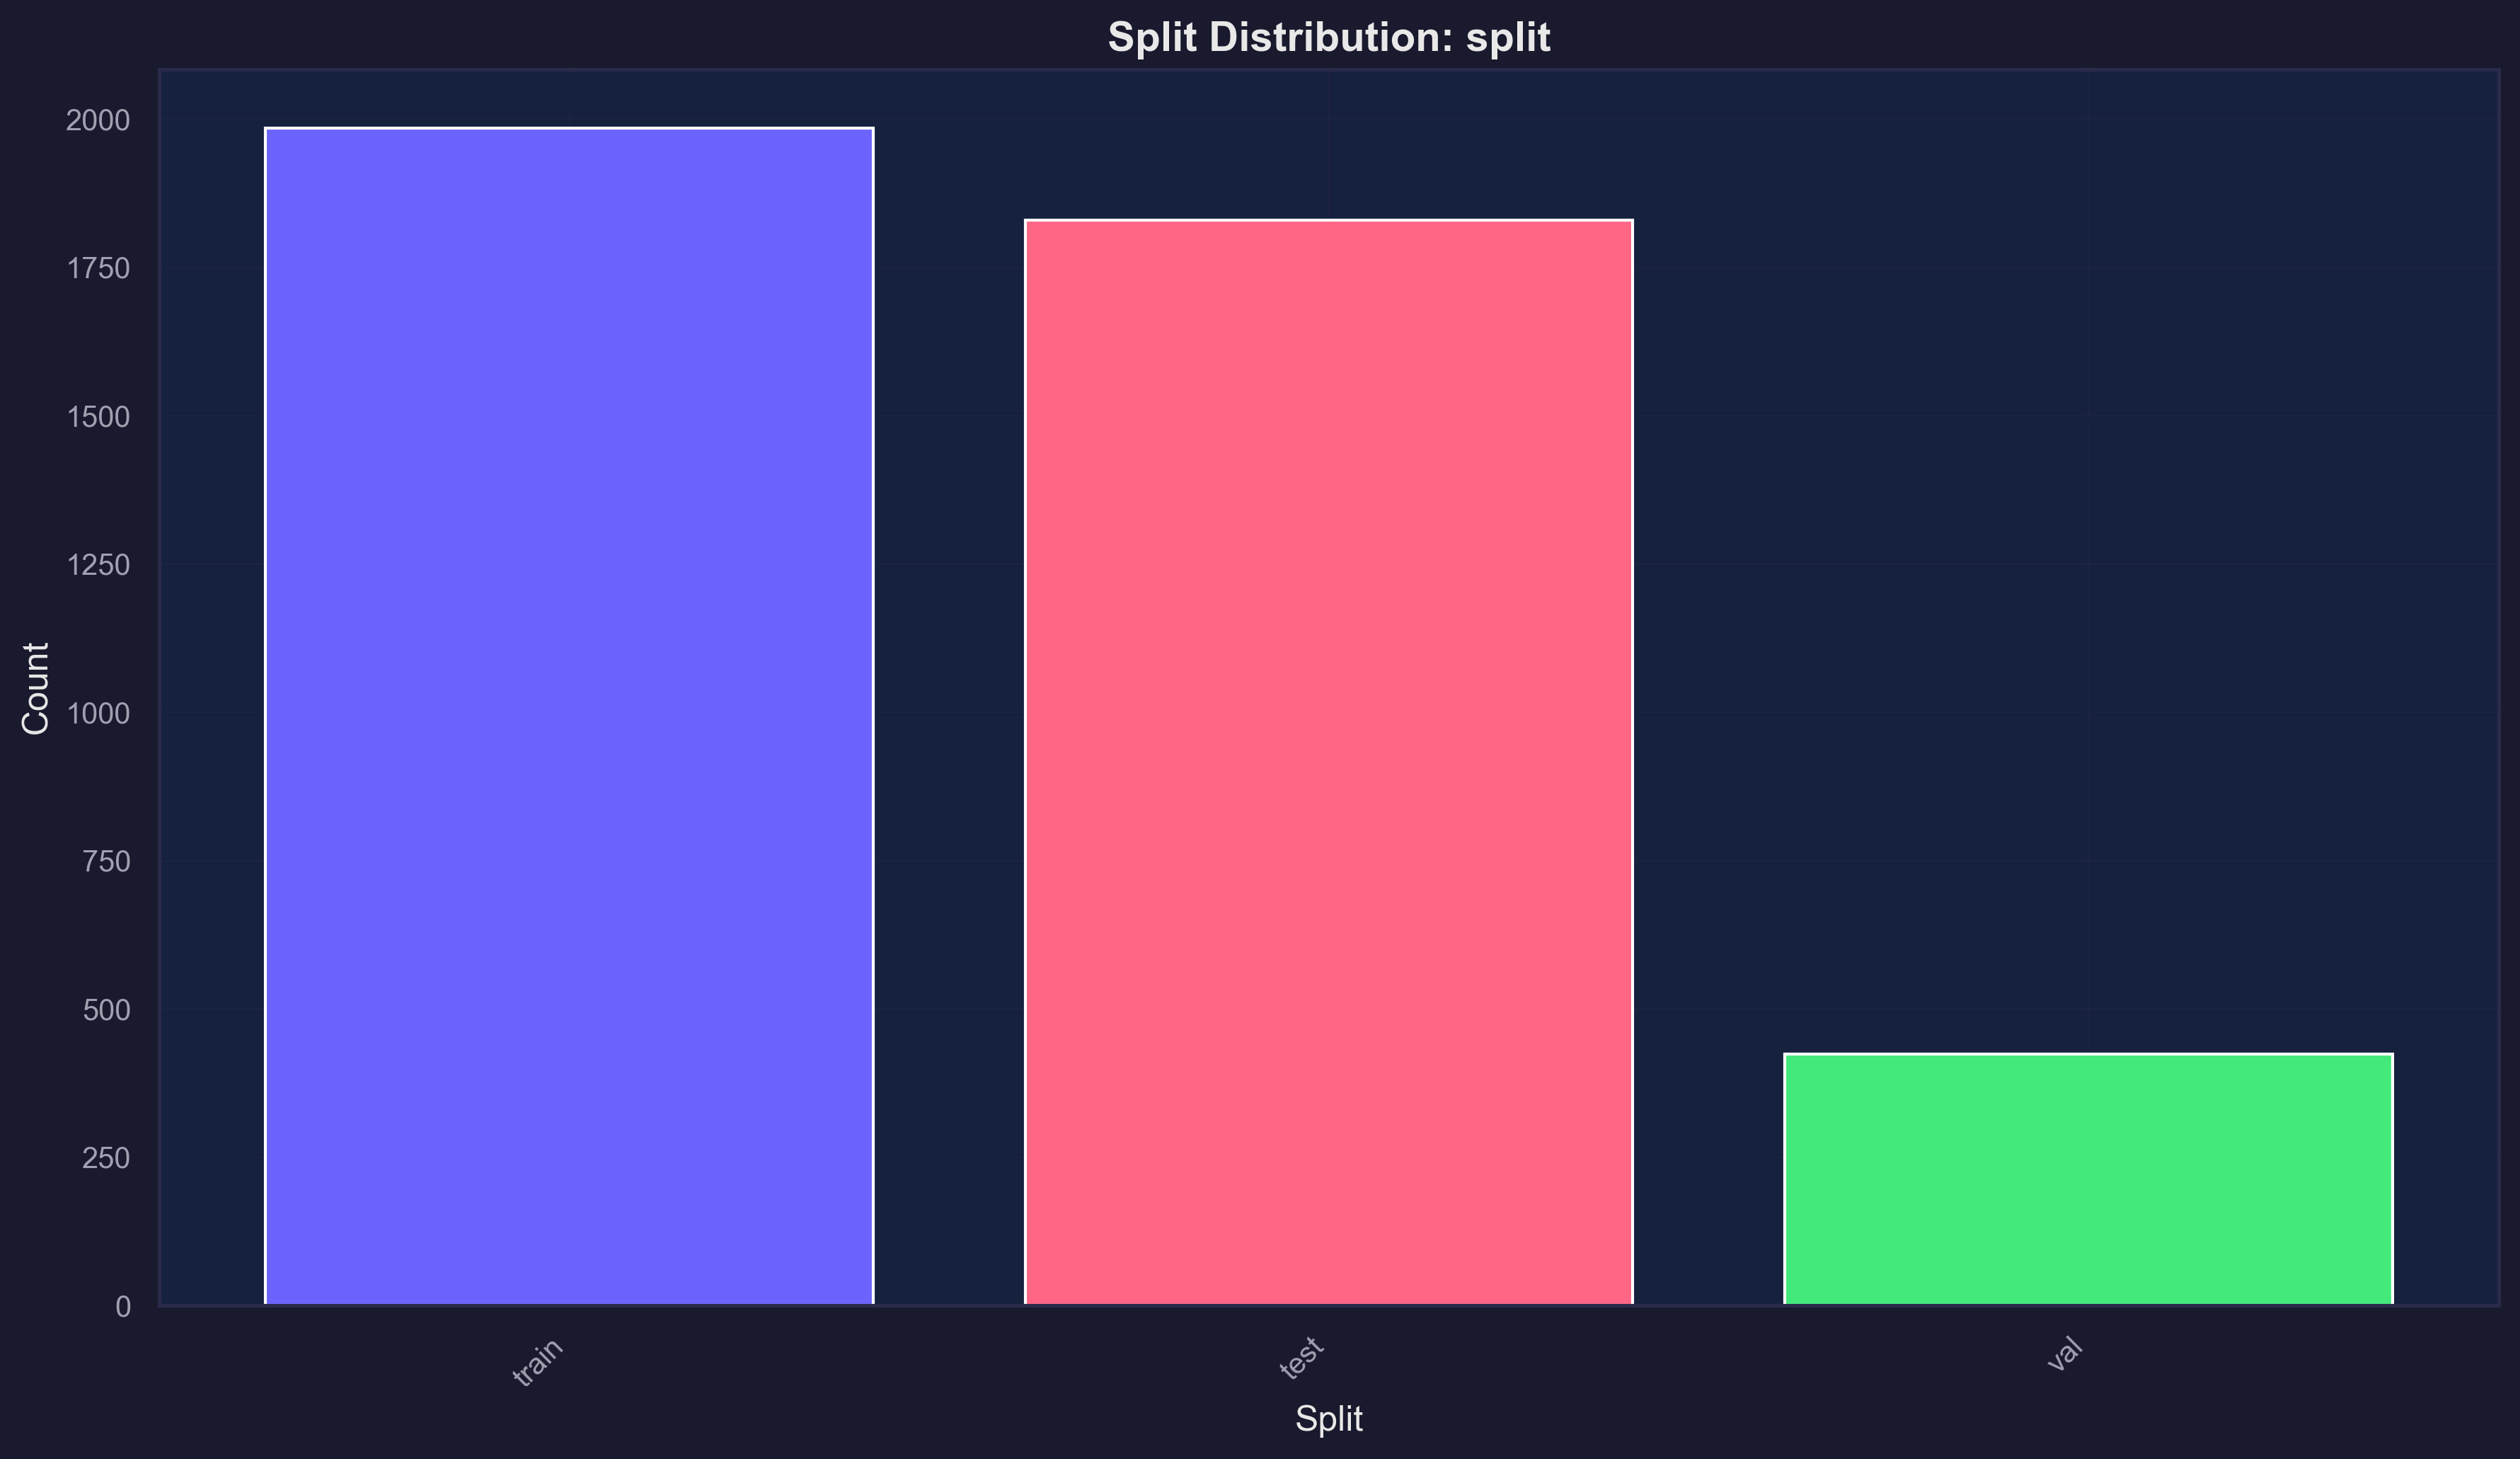

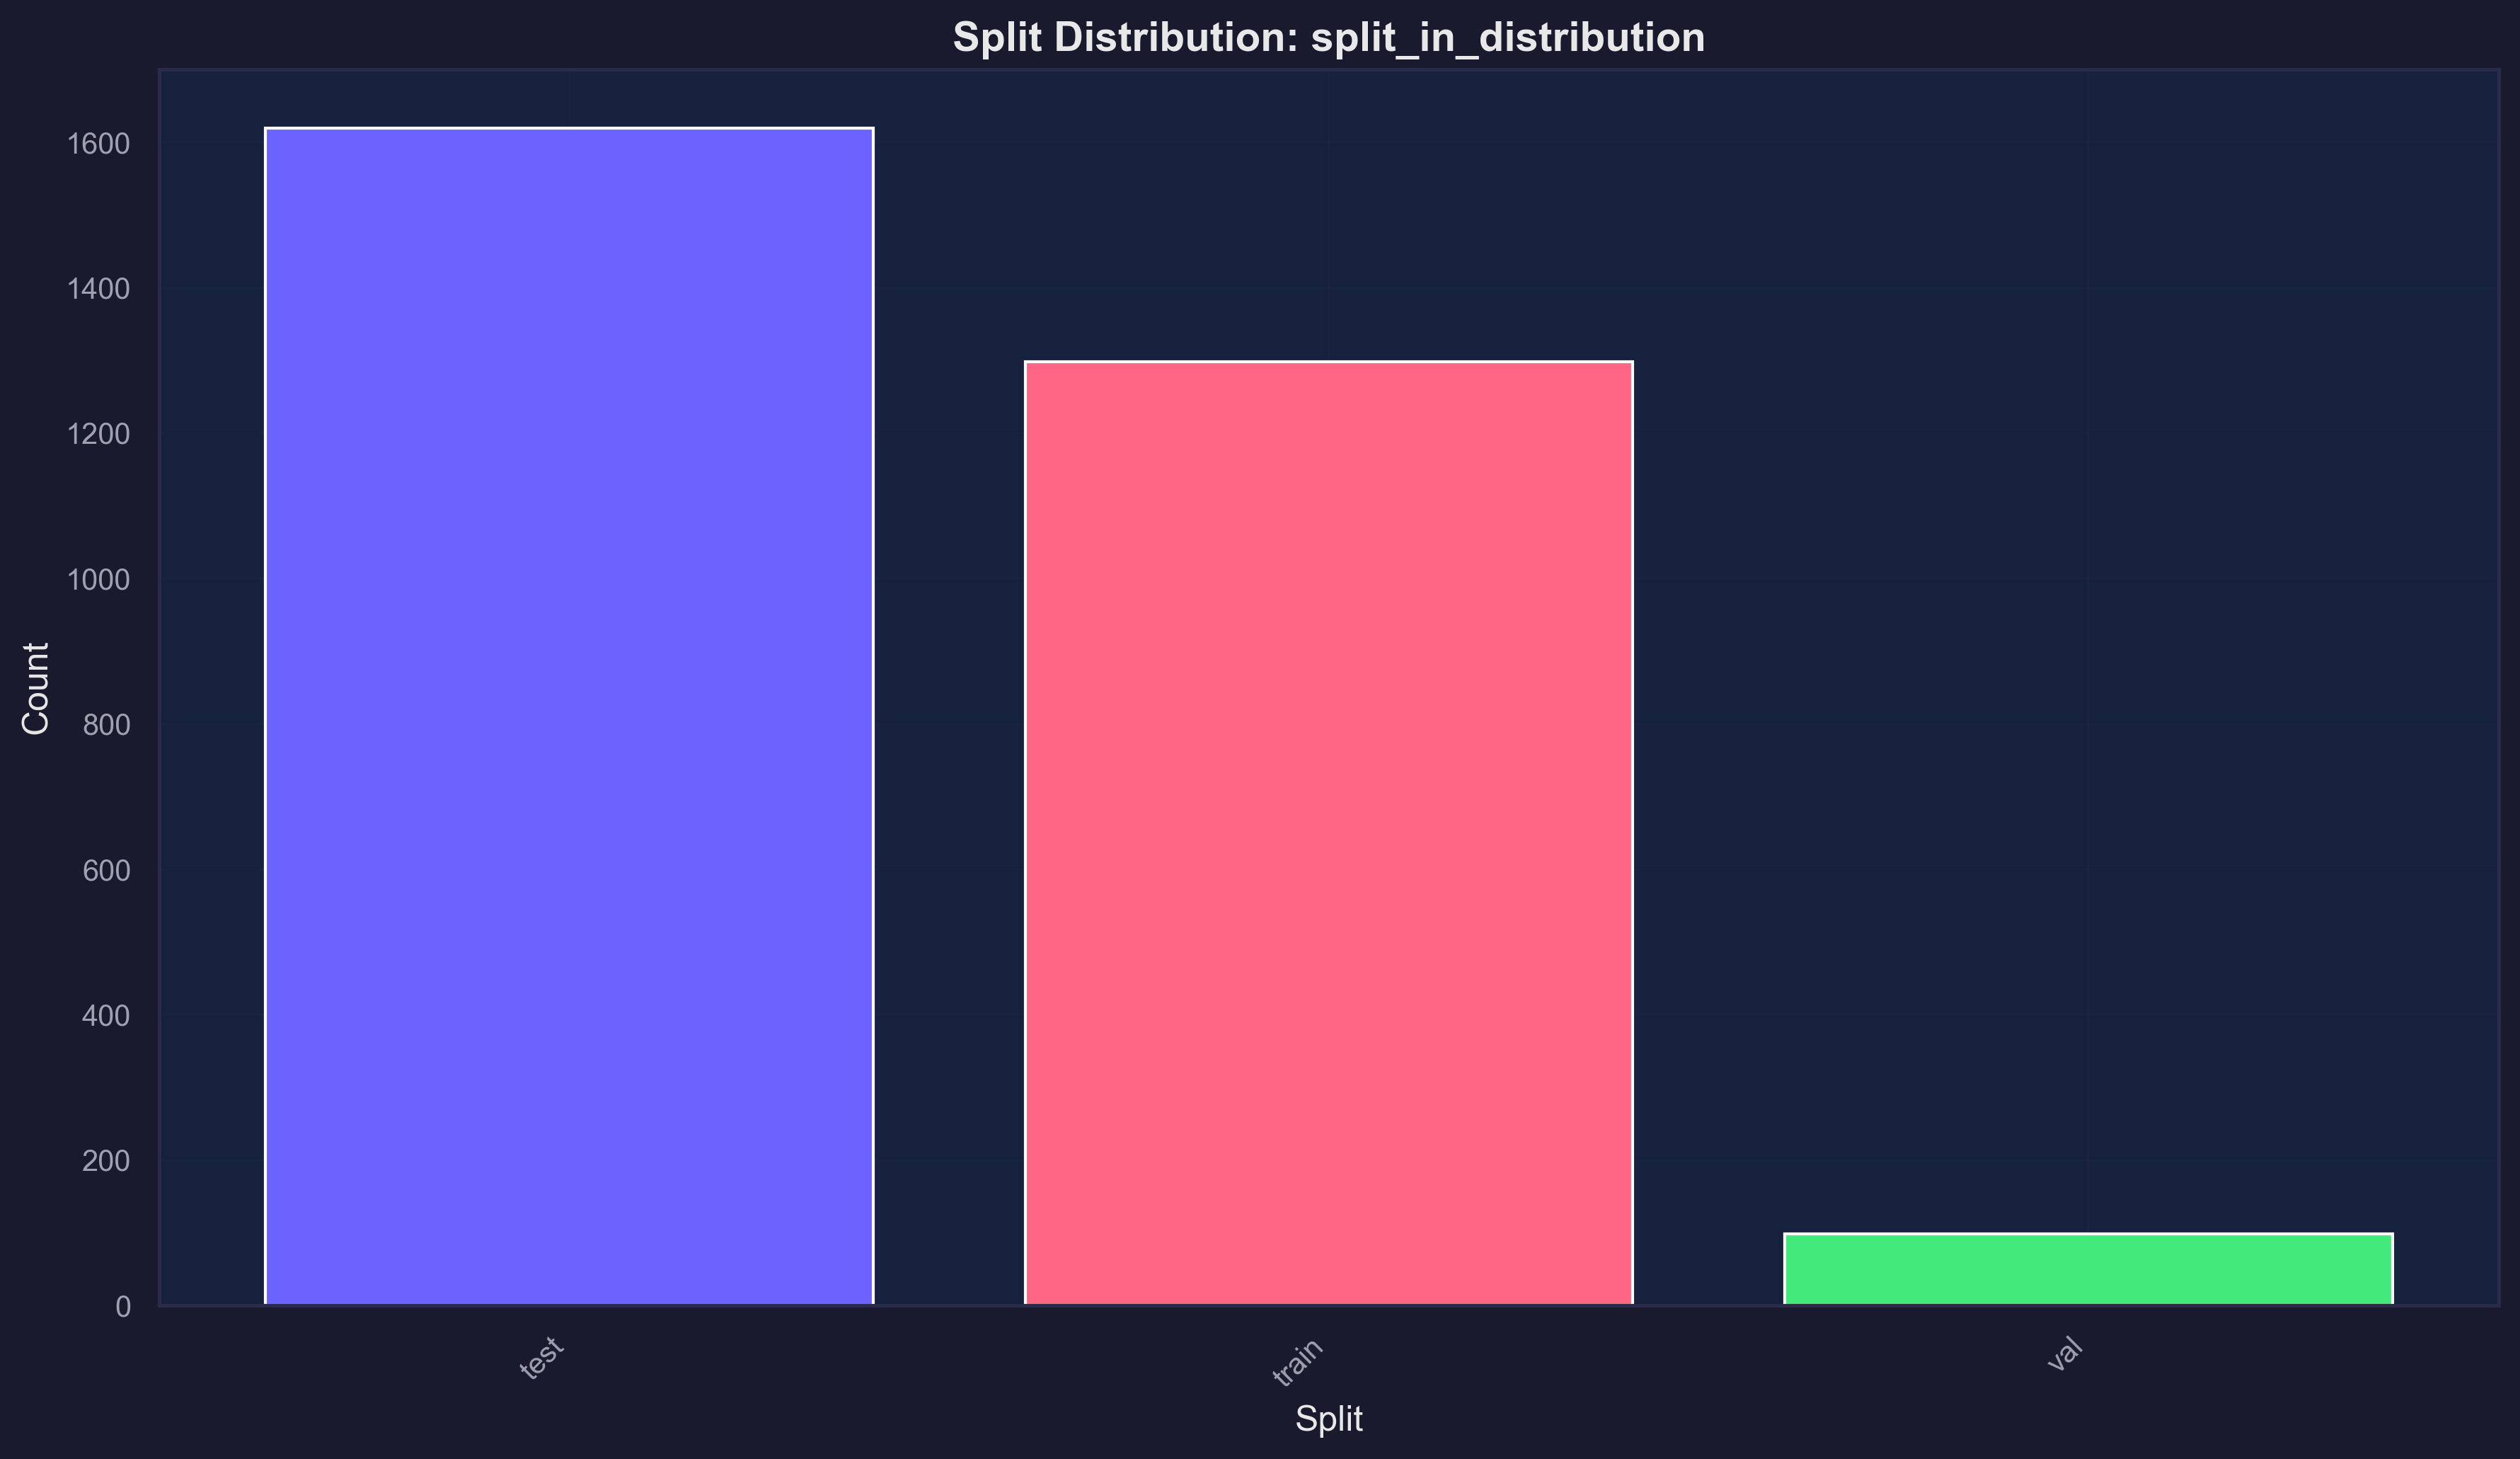

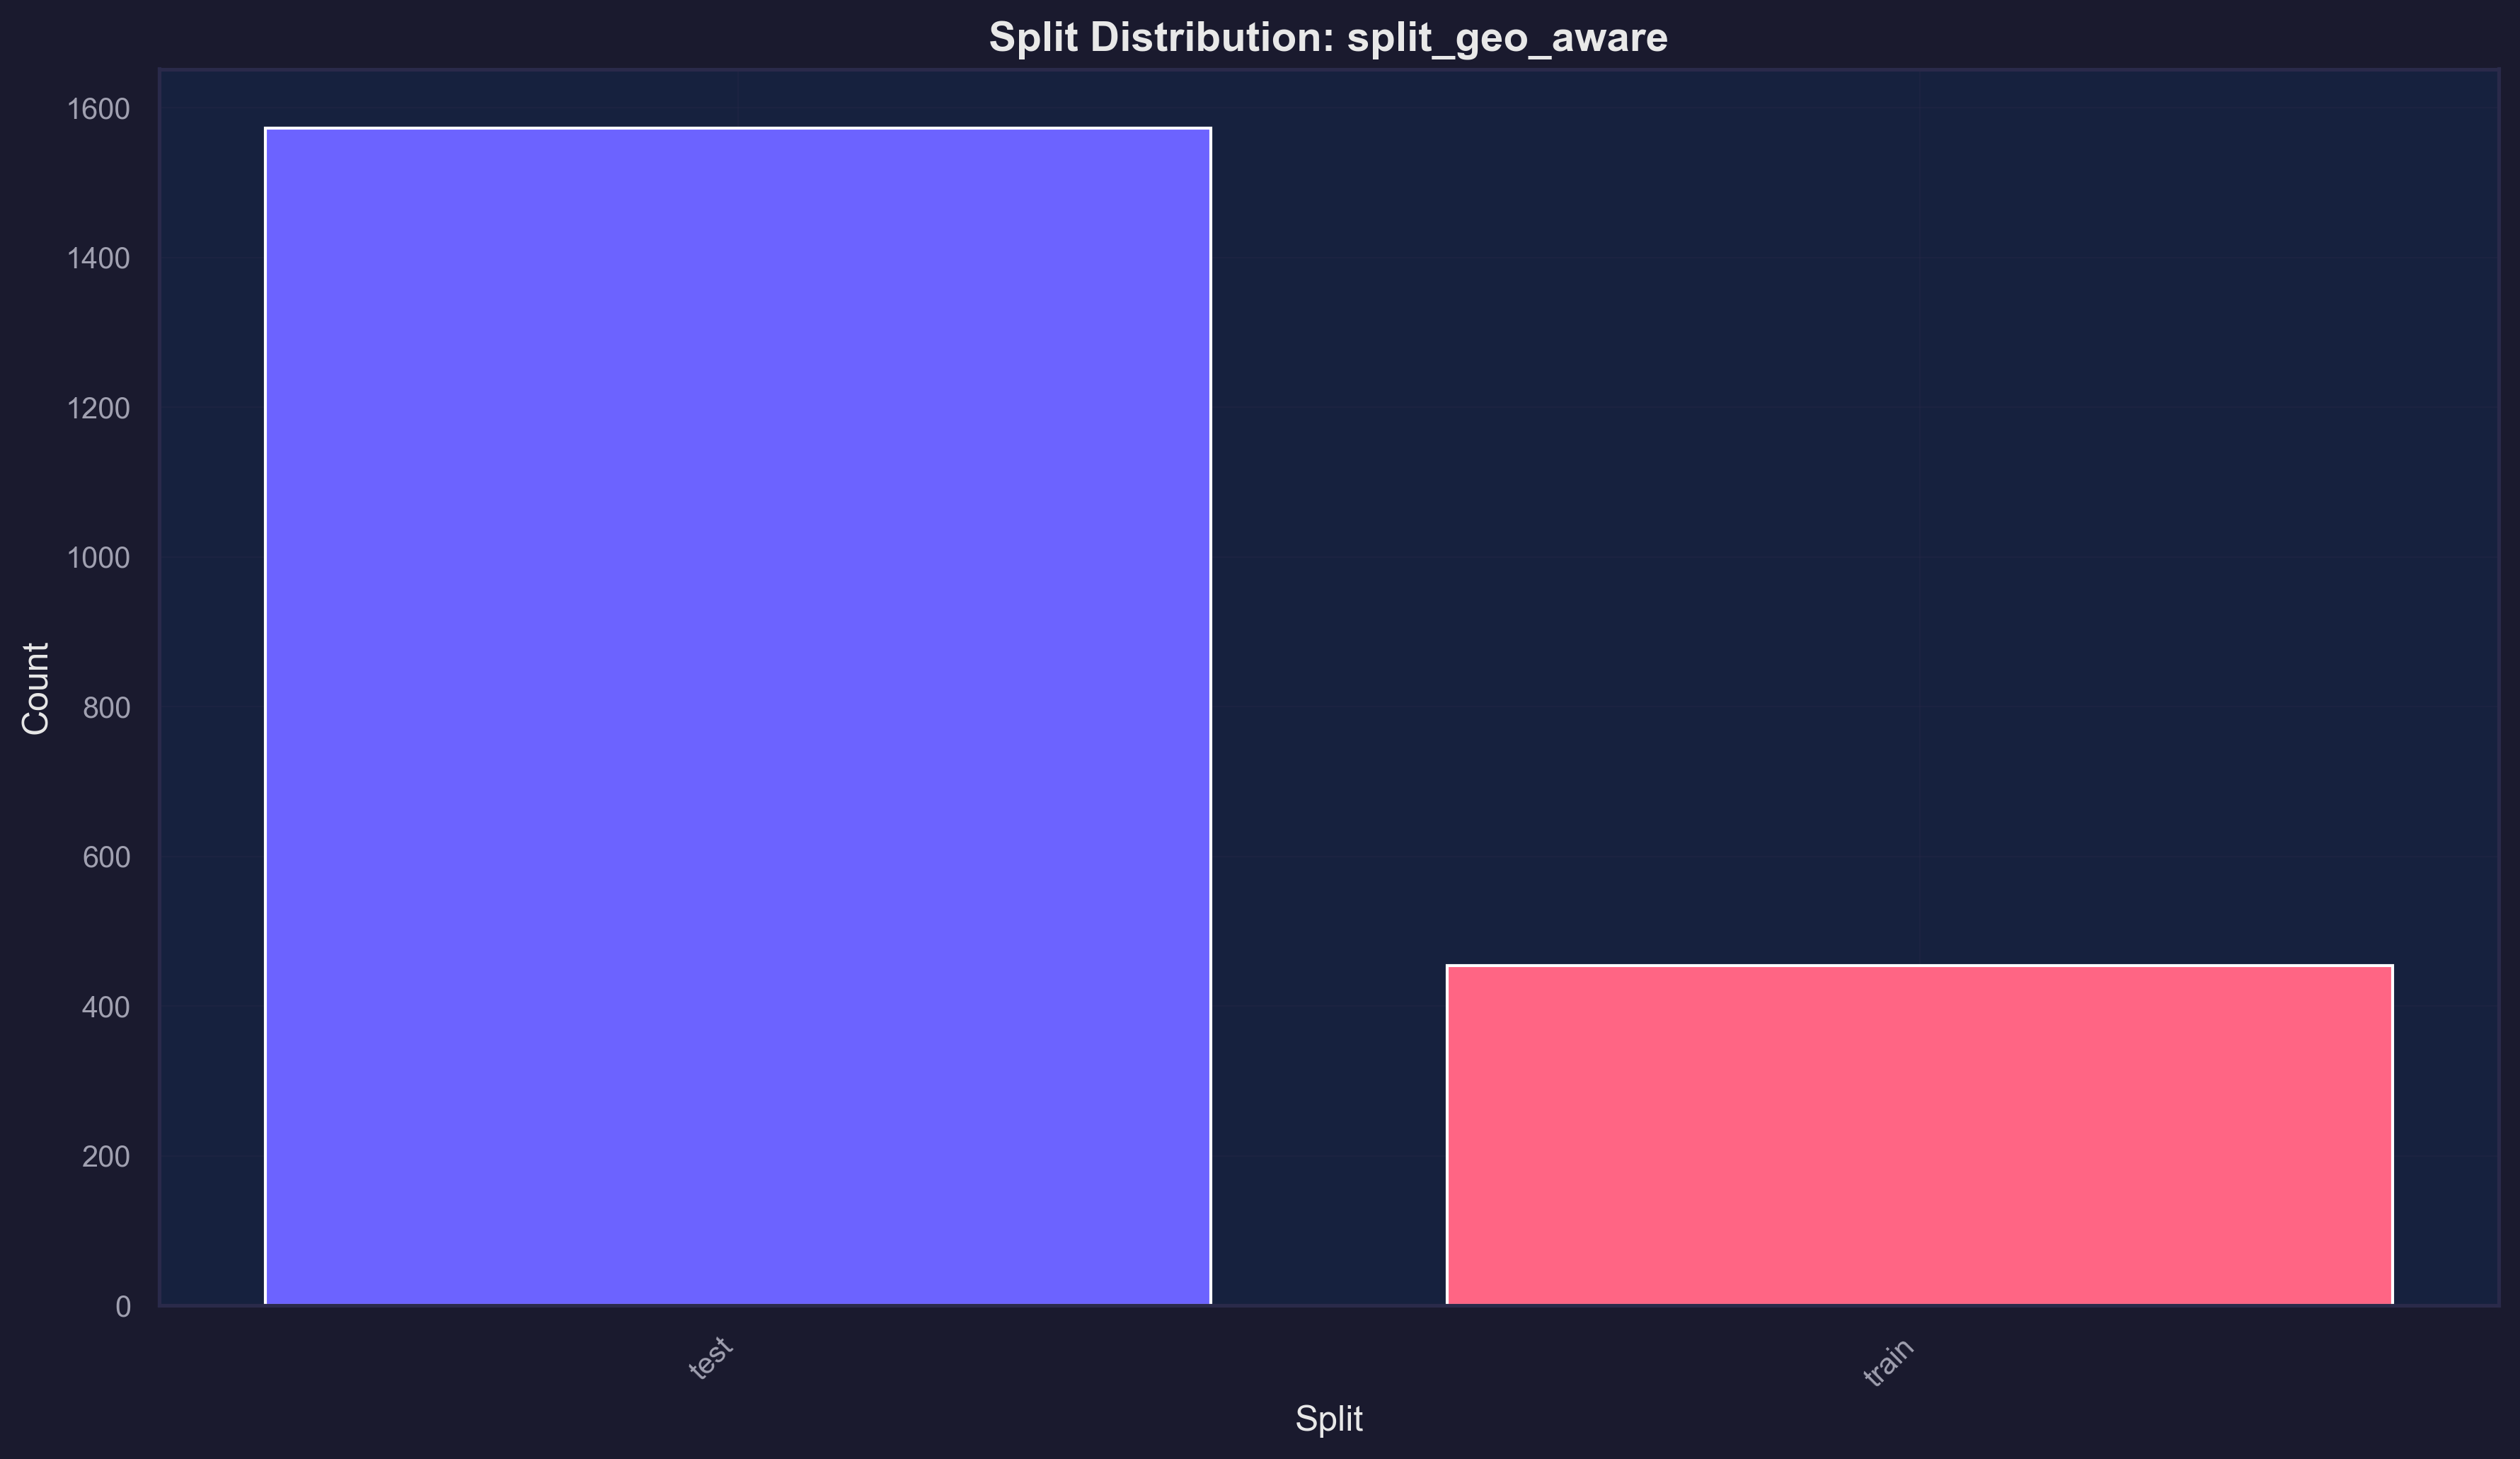

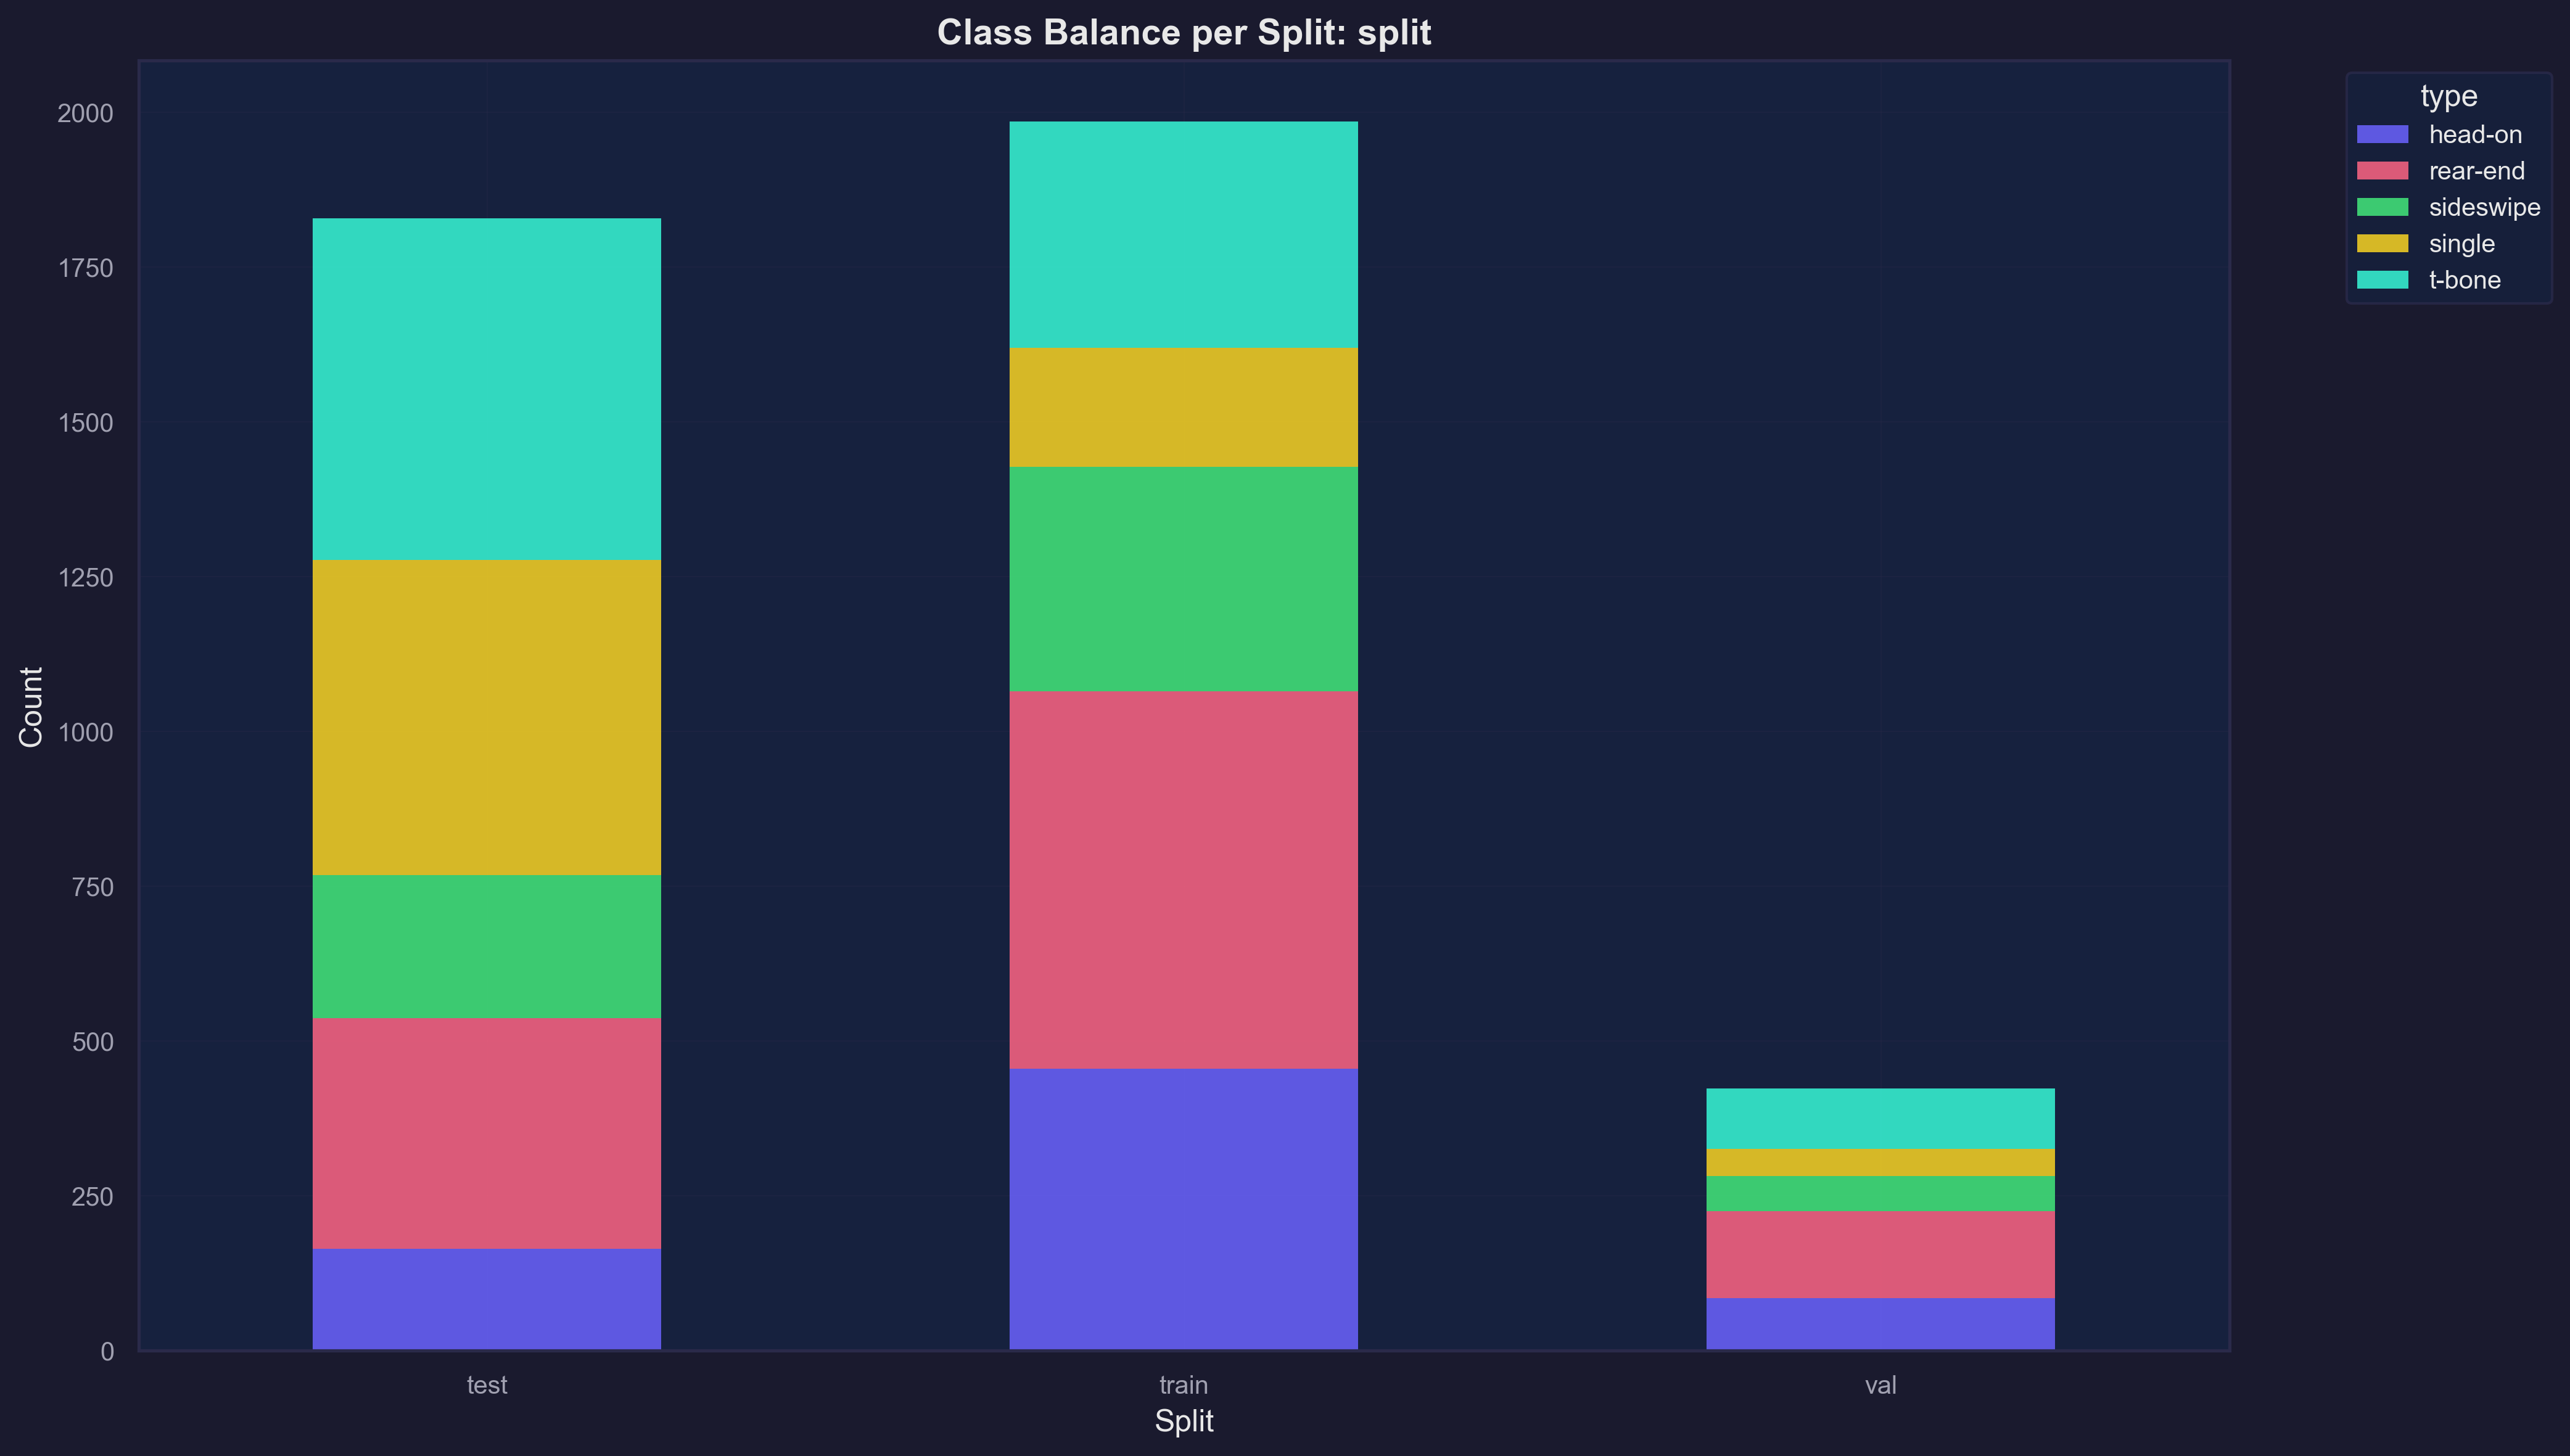

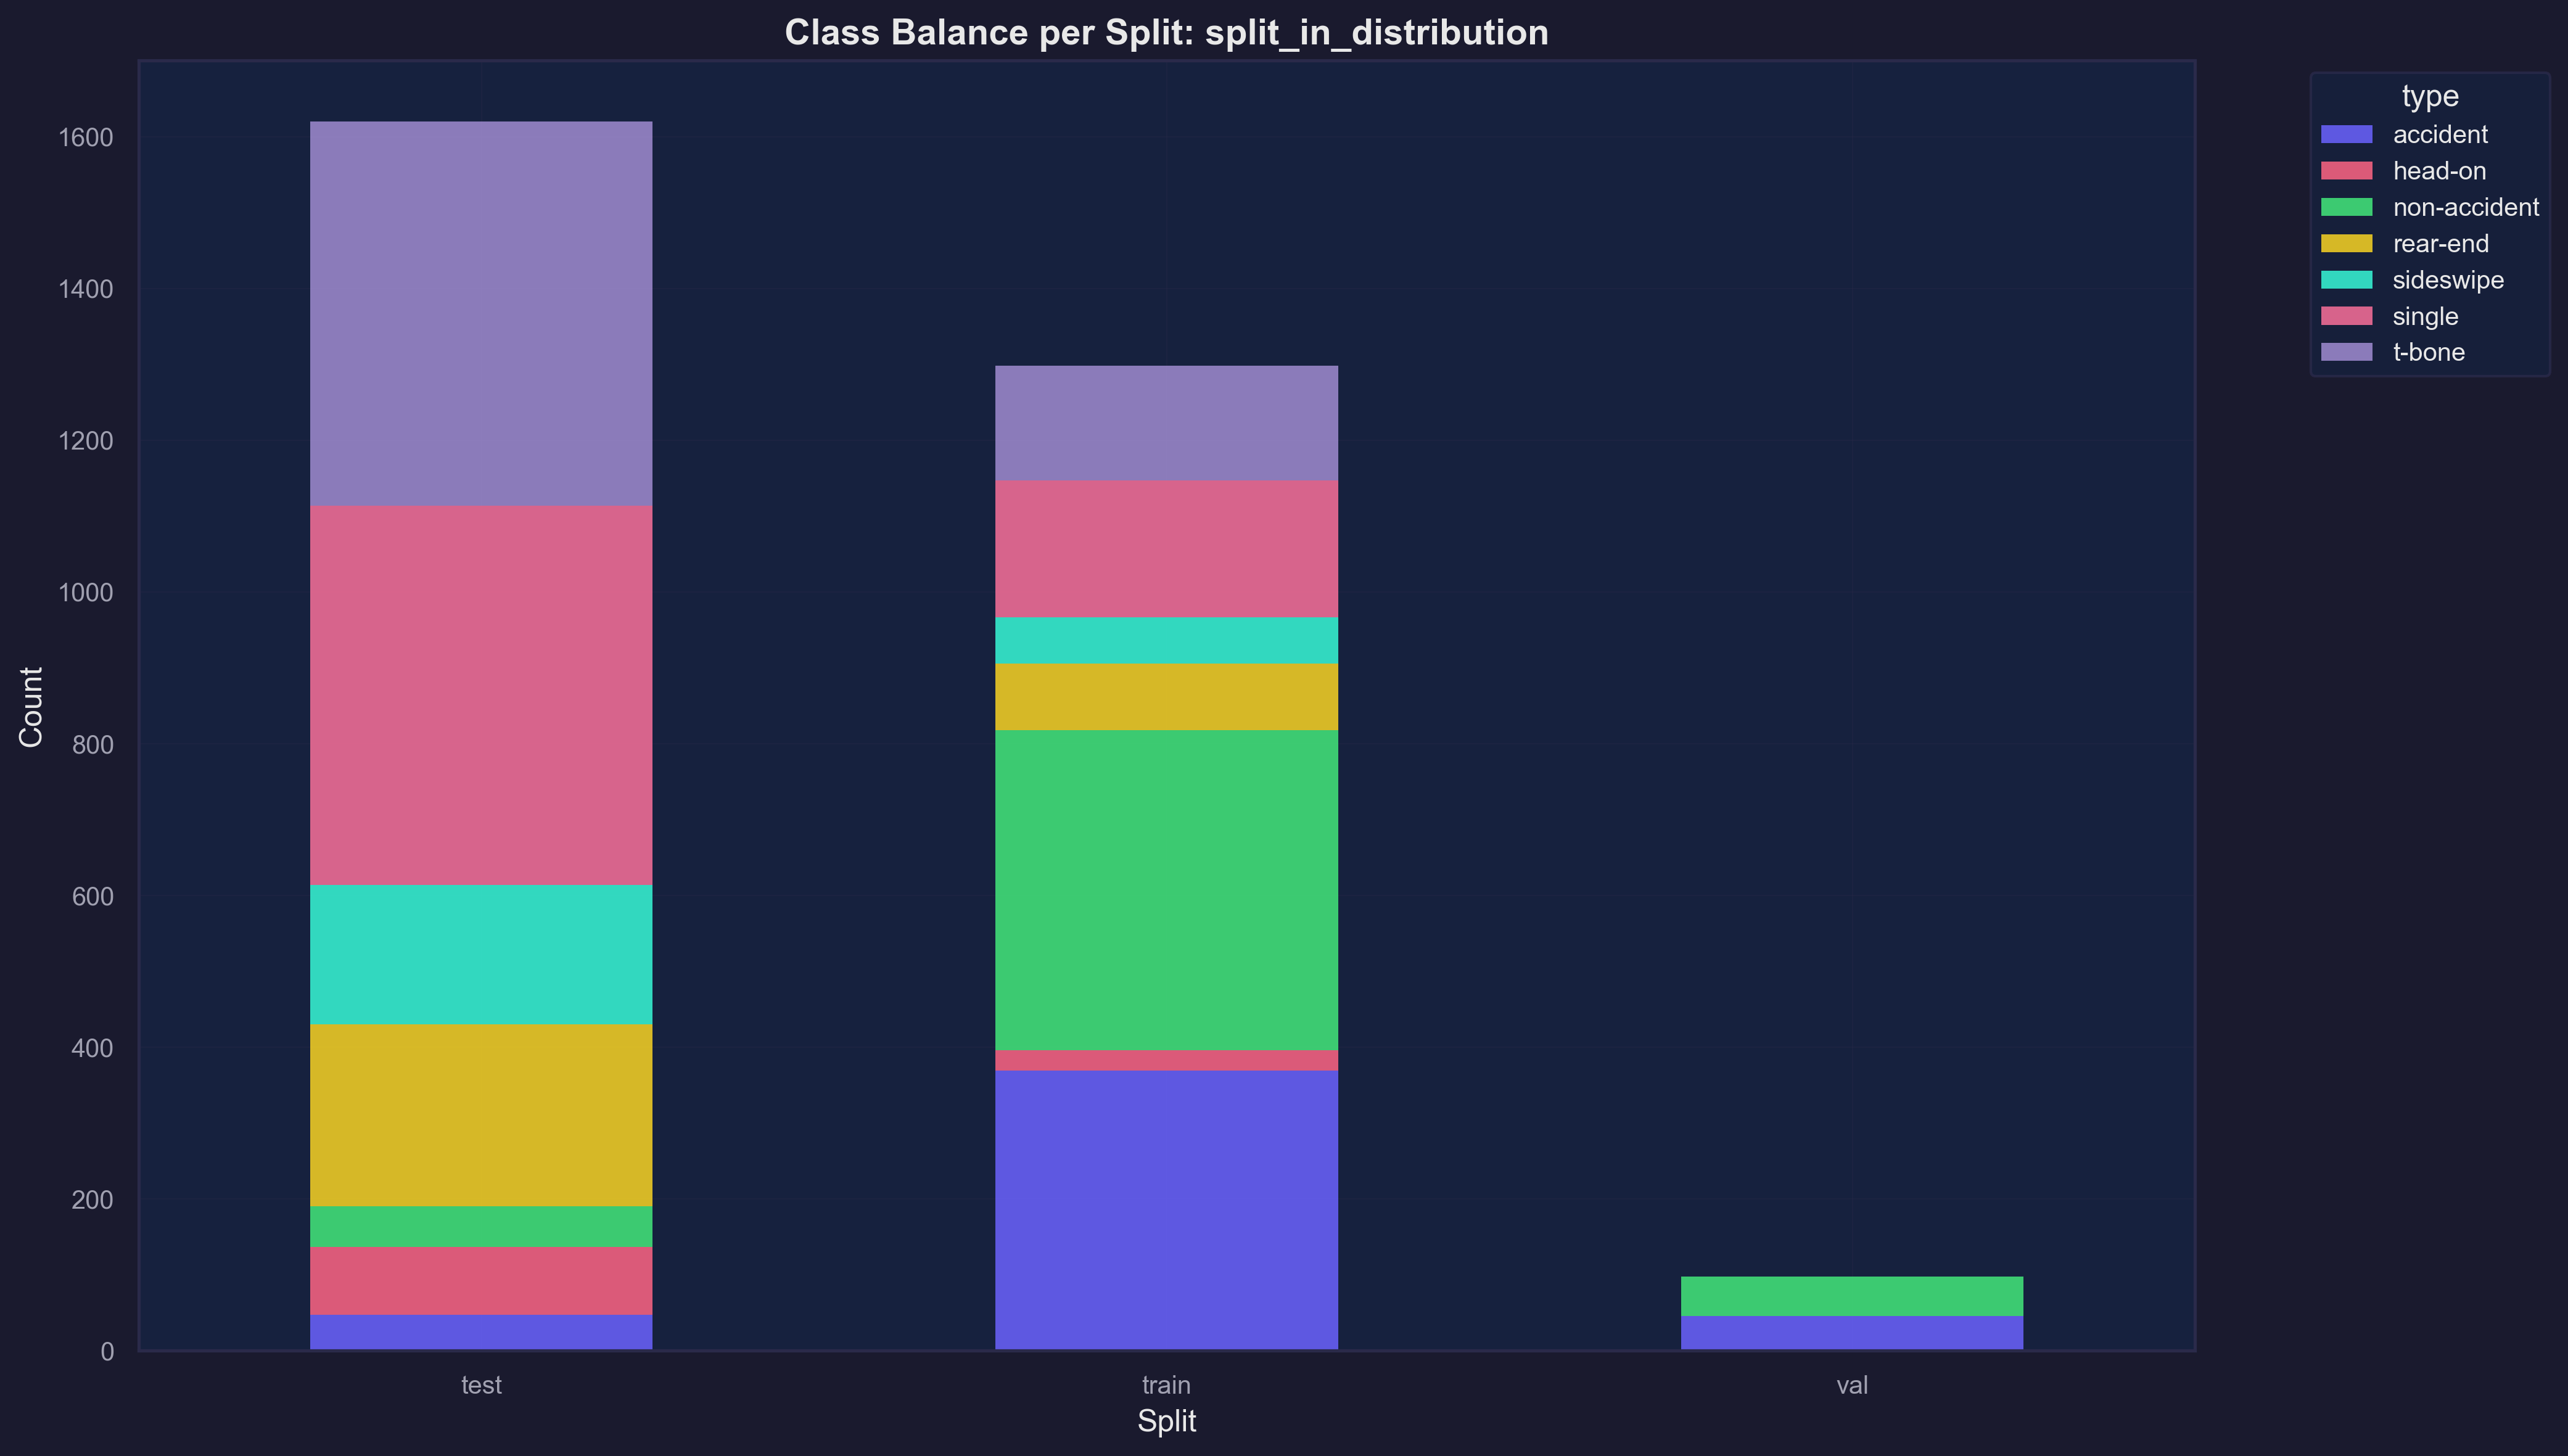

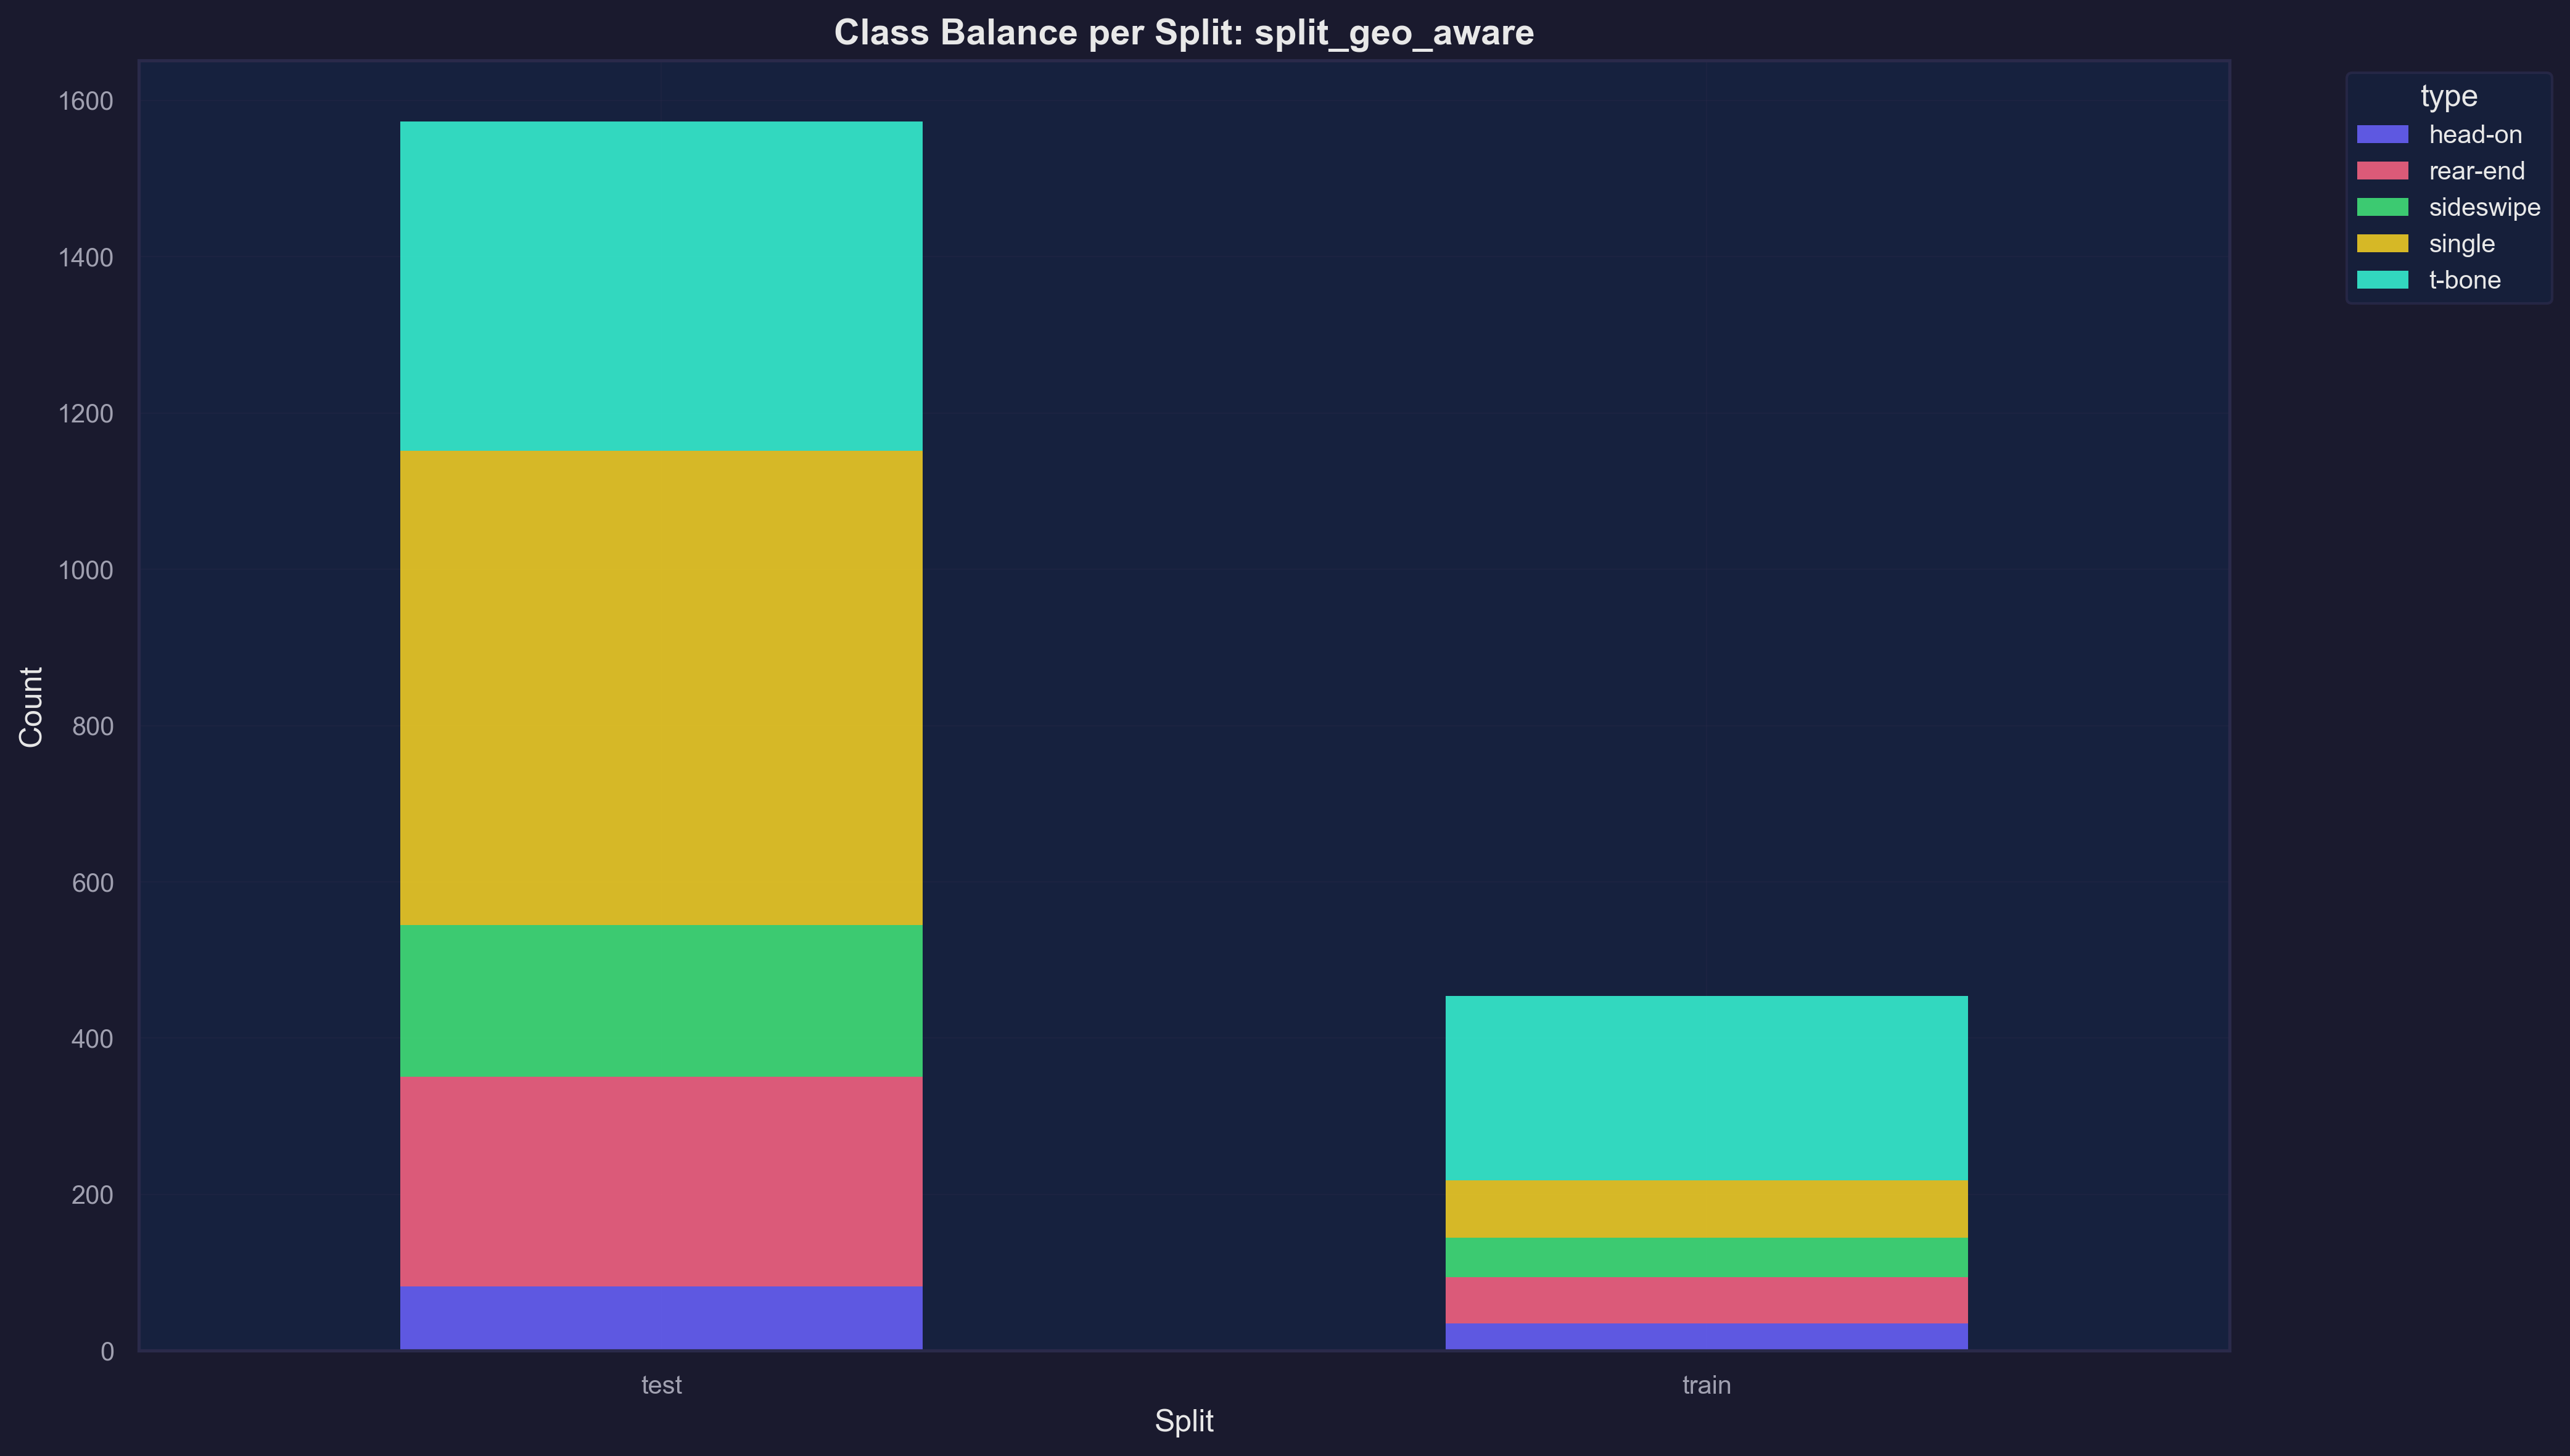

In [4]:
if results.get("available"):
    split_cols = results["split_columns"]

    # Split distribution bar charts — one per split column
    for col in split_cols:
        if col in df.columns and df[col].notna().any():
            fig, ax = plot_engine.create_figure(figsize=(12, 7))
            plot_engine.plot_bar_chart(
                df[col].dropna(),
                title=f"Split Distribution: {col}",
                xlabel="Split",
                ax=ax,
            )
            plt.tight_layout()
            output.save_figure(fig, f"{col}_distribution")
            wb.log_figure(fig, f"{col}_distribution")
            plt.show()

    # Class balance per split strategy (grouped bars)
    label_col = config.primary_label
    if label_col in df.columns:
        for col in split_cols:
            col_data = results.get(col, {})
            class_balance = col_data.get("class_balance", {})
            if class_balance.get("available") is False:
                continue

            # Build a cross-tab for plotting
            valid = df[[col, label_col]].dropna()
            if valid.empty:
                continue
            ct = pd.crosstab(valid[col], valid[label_col])
            if ct.empty:
                continue

            fig, ax = plot_engine.create_figure(figsize=(14, 8))
            ct.plot(
                kind="bar", stacked=True, ax=ax,
                color=CATEGORICAL_COLOURS[:ct.shape[1]],
                edgecolor="none", alpha=0.85,
            )
            ax.set_title(f"Class Balance per Split: {col}", fontweight="bold")
            ax.set_xlabel("Split")
            ax.set_ylabel("Count")
            ax.legend(title=label_col, bbox_to_anchor=(1.05, 1), loc="upper left")
            plt.xticks(rotation=0)
            plt.tight_layout()
            output.save_figure(fig, f"{col}_class_balance")
            wb.log_figure(fig, f"{col}_class_balance")
            plt.show()

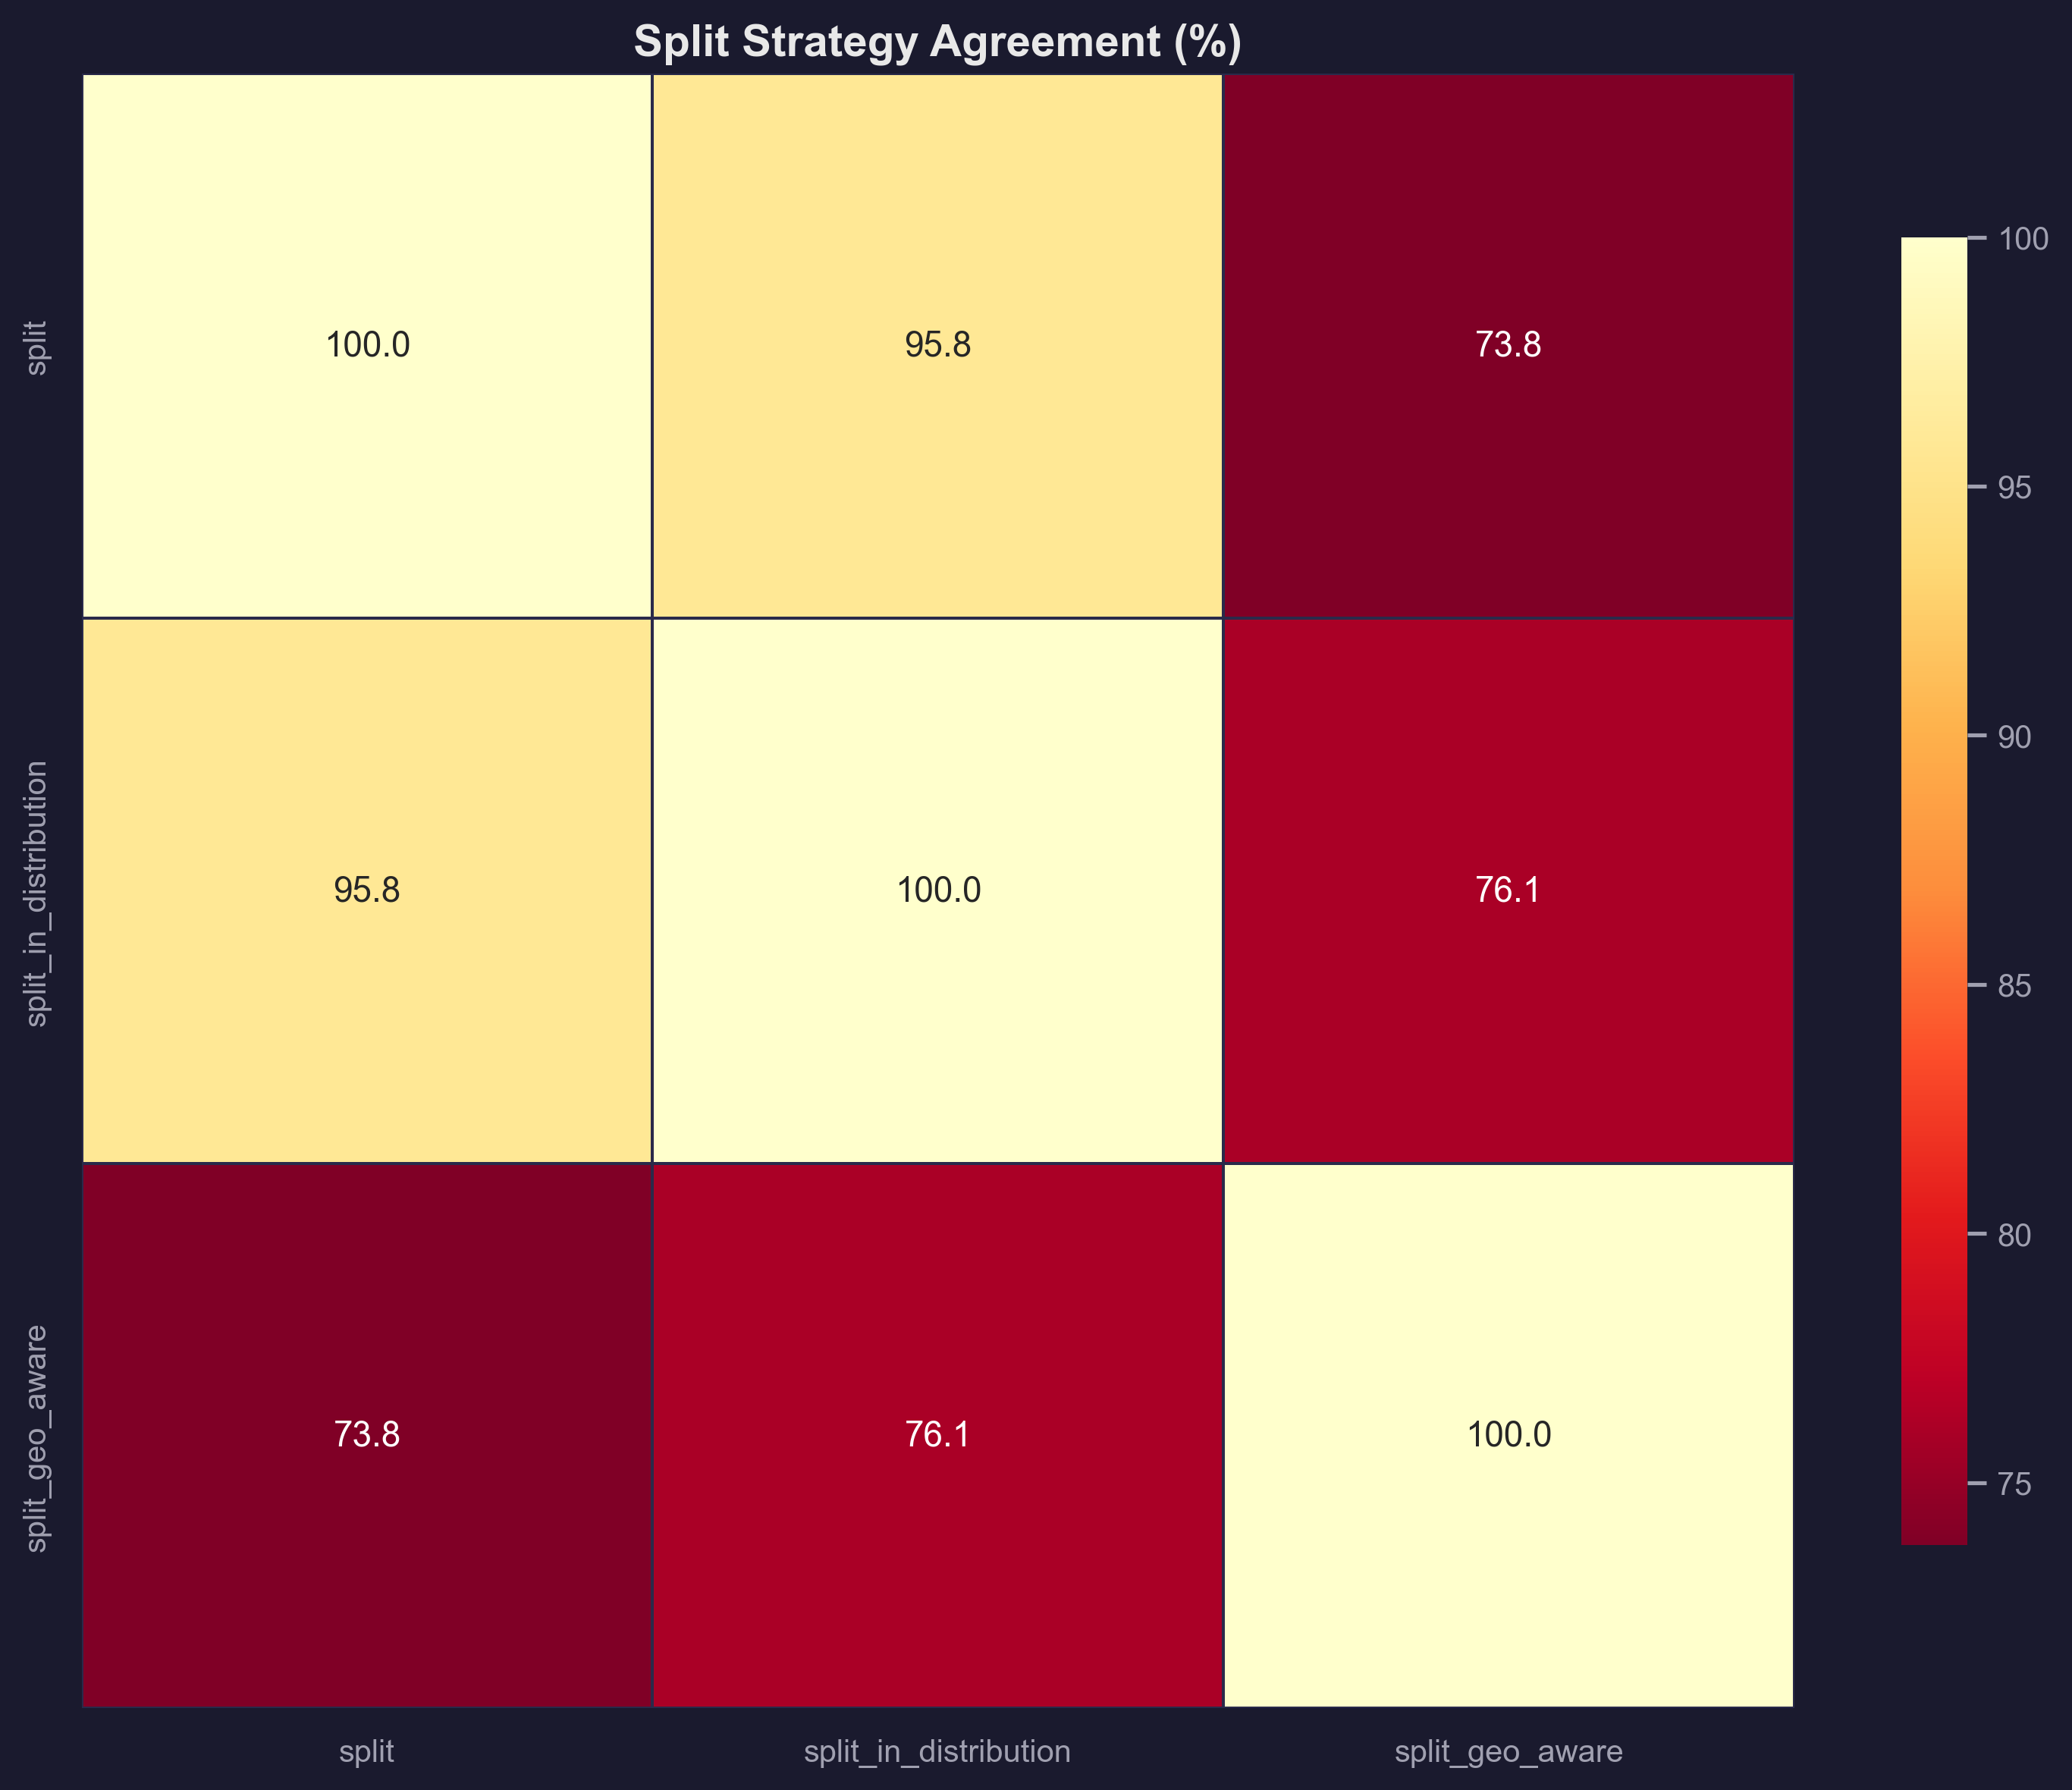

In [5]:
# Strategy agreement heatmap
comp = results.get("strategy_comparison", {})
if comp.get("available") and comp.get("comparisons"):
    comparisons = comp["comparisons"]
    # Build a matrix of agreement percentages
    split_cols = results["split_columns"]
    agree_matrix = pd.DataFrame(
        100.0, index=split_cols, columns=split_cols,
    )
    for key, info in comparisons.items():
        parts = key.split("_vs_")
        if len(parts) == 2:
            c1, c2 = parts
            pct = info["agreement_percent"]
            agree_matrix.loc[c1, c2] = pct
            agree_matrix.loc[c2, c1] = pct

    fig, ax = plot_engine.create_figure(figsize=(10, 8))
    plot_engine.plot_heatmap(
        agree_matrix,
        title="Split Strategy Agreement (%)",
        fmt=".1f",
        cmap="YlOrRd_r",
        ax=ax,
    )
    plt.tight_layout()
    output.save_figure(fig, "split_agreement_heatmap")
    wb.log_figure(fig, "split_agreement_heatmap")
    plt.show()

## Report & Export

In [6]:
rg = ReportGenerator(
    NOTEBOOK_NAME,
    eda_version=config.eda_version,
    dataset_version=loader.dataset_version,
    metadata_hash=metadata_hash,
    git_commit=git_commit,
    seed=config.seed,
)

if results.get("available"):
    split_cols = results["split_columns"]

    # Split distribution tables
    rg.add_heading("Split Distributions")
    comp_rows = []
    for col in split_cols:
        col_data = results.get(col, {})
        dist = col_data.get("distribution", {})
        if dist:
            for val, cnt in dist.get("counts", {}).items():
                pct = dist["percentages"].get(val, 0)
                comp_rows.append({
                    "split_column": col, "split_value": val,
                    "count": cnt, "percent": pct,
                })
    if comp_rows:
        comp_df = pd.DataFrame(comp_rows)
        rg.add_table(comp_df, key="split_comparison")
        output.save_csv(comp_df, "split_comparison")

    # Class balance per split CSV
    rg.add_heading("Class Balance per Split")
    balance_rows = []
    label_col = config.primary_label
    for col in split_cols:
        col_data = results.get(col, {})
        cb = col_data.get("class_balance", {})
        if isinstance(cb, dict) and cb.get("available") is not False:
            for split_val, info in cb.items():
                if split_val == "available":
                    continue
                for cls, cnt in info.get("distribution", {}).items():
                    pct = info["percentages"].get(cls, 0)
                    balance_rows.append({
                        "split_column": col, "split_value": split_val,
                        "class": cls, "count": cnt, "percent": pct,
                    })
    if balance_rows:
        bal_df = pd.DataFrame(balance_rows)
        rg.add_table(bal_df.head(50), key="split_class_balance")
        output.save_csv(bal_df, "split_class_balance")

    # Strategy comparison stats
    rg.add_heading("Strategy Comparison")
    comparison = results.get("strategy_comparison", {})
    if comparison.get("available"):
        for key, info in comparison.get("comparisons", {}).items():
            rg.add_key_value_list({
                "Comparison": key,
                "Agreement": f"{info['agreement_percent']:.1f}%",
                "Disagreement": f"{info['disagreement_percent']:.1f}%",
            })

    # Leakage summary
    rg.add_heading("Leakage Indicators")
    leakage = results.get("leakage_indicators", {})
    if leakage:
        rg.add_key_value_list({
            k: str(v) for k, v in leakage.items()
        })


    # Warnings
    warnings = results.get("warnings", [])
    if warnings:
        rg.add_heading("Analysis Warnings")
        for w in warnings:
            rg.add_warning(w)

    rg.add_stats({
        "split_columns": split_cols,
        "strategy_agreement": {
            k: v.get("agreement_percent", 0)
            for k, v in comparison.get("comparisons", {}).items()
        } if comparison.get("available") else {},
    })

output.save_report(rg.build_markdown(), "split_analysis_report")
output.save_summary_json(rg.build_summary_json(), "summary")

# W&B logging
wb.log_stats({"split/columns_analyzed": len(results.get("split_columns", []))})
if comp_rows:
    wb.log_table(pd.DataFrame(comp_rows), "split_comparison")

print("Reports and exports saved.")

Reports and exports saved.


## Teardown

In [7]:
snap_end = monitor.snapshot("end")
duration = time.time() - START_TIME

wb.log_system_info(snap_end)
wb.log_stats({"execution/duration_seconds": round(duration, 2)})
wb.log_notebook_outputs(
    output.figures_dir, output.reports_dir, output.exports_dir,
    metadata={"notebook": NOTEBOOK_NAME, "duration": round(duration, 2)},
)

output.finalize(
    wandb_run_id=wb.run_id, wandb_run_url=wb.run_url,
    git_commit=git_commit, metadata_hash=metadata_hash,
    rows_analyzed=df.shape[0], duration_seconds=duration,
)
logger.log_execution_summary(
    duration_seconds=duration, files_exported=output.all_exported_files,
    wandb_run_id=wb.run_id, wandb_run_url=wb.run_url,
)
wb.finish()

print(f"\n✅ Notebook complete in {duration:.1f}s")
print(f"   Exported {len(output.all_exported_files)} files")

wandb: Adding directory to artifact (E:\Rads\eda\figures\2026-08-01_16-41)... 

Done. 0.2s


wandb: Adding directory to artifact (E:\Rads\eda\reports\2026-08-01_16-41)... 

Done. 0.0s


wandb: Adding directory to artifact (E:\Rads\eda\exports\2026-08-01_16-41)... 

...

wandb: uploading summary, console lines 38-39


wandb: 
wandb: Run history:
wandb: execution/duration_seconds ▁
wandb:     split/columns_analyzed ▁
wandb:           system/cpu/cores ▁▁
wandb:         system/cpu/percent █▁
wandb:        system/disk/percent ▁▁
wandb:        system/disk/used_gb ▁▁
wandb:      system/memory/percent █▁
wandb:     system/memory/total_gb ▁▁
wandb:      system/memory/used_gb ▁▁
wandb: 
wandb: Run summary:
wandb: execution/duration_seconds 34.57
wandb:     split/columns_analyzed 3
wandb:           system/cpu/cores 4
wandb:         system/cpu/percent 32.8
wandb:        system/disk/percent 68.7
wandb:        system/disk/used_gb 151.99
wandb:      system/memory/percent 95.9
wandb:     system/memory/total_gb 7.74
wandb:      system/memory/used_gb 7.43
wandb: 


wandb:  View run eda-05_split_analysis at: https://wandb.ai/saksham4data-vinkura/RADS/runs/zs9wjiax
wandb:  View project at: https://wandb.ai/saksham4data-vinkura/RADS
wandb: Synced 5 W&B file(s), 8 media file(s), 21 artifact file(s) and 0 other file(s)


wandb: Find logs at: .\wandb\run-20260801_221121-zs9wjiax\logs



✅ Notebook complete in 34.6s
   Exported 18 files
